# CranioVision — Grad-CAM Explainability Demo

**What this notebook shows:**

1. Run Grad-CAM on the trained Attention U-Net
2. Generate heatmaps for each tumor class — what the model "looks at" to make its predictions
3. Overlay heatmaps on MRI slices to verify the model is looking at *tumor regions* (not skull / noise)
4. Compare attention across the 3 tumor classes side-by-side

**Clinical value:**  
If the model predicts "enhancing tumor" somewhere — we should see high Grad-CAM activation in that exact area. If the heatmap is random or focused outside the tumor, we should NOT trust the prediction.

**Runtime:** ~2 min on GTX 1650 4GB (patch-based, not full volume)

## 1. Setup

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

from src.cranovision.config import MODELS_DIR, OUTPUTS_DIR, CLASS_NAMES
from src.cranovision.data import get_splits
from src.cranovision.inference import (
    load_model,
    compute_grad_cam,
    compute_region_volumes,
)

print('✅ Imports ok')

c:\Users\hrana\anaconda3\envs\ml_env_fixed\Lib\site-packages\ignite\handlers\checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


✅ Imports ok


## 2. Load model + pick a case

In [2]:
ckpt_path = MODELS_DIR / 'attention_unet_best.pth'
model = load_model('attention_unet', ckpt_path)

_, _, test_cases = get_splits()
print(f'\nAvailable test cases: {len(test_cases)}')

Loading attention_unet from attention_unet_best.pth...
  ✓ Loaded. Device: cuda
Scanning 200 patient folders in BraTS2024_small_dataset/
  Valid cases: 200
Loading existing split from data_split.json
  Train: 140 (70%) | Val: 30 (15%) | Test: 30 (15%)

Available test cases: 30


In [3]:
# Try different indices to see how the model reasons on different patients
# Index 0 = well-segmented, Index 4 = hard (ET=0), Index 13 = partial fail
CASE_IDX = 0
case = test_cases[CASE_IDX]
print(f'Target case: {case["case_id"]}')

Target case: BraTS-GLI-02196-105


## 3. Run Grad-CAM

Generates 3 heatmaps — one for each tumor class. Takes ~1-2 minutes.

In [4]:
result = compute_grad_cam(
    model=model,
    case_dict=case,
    model_name='attention_unet',
    target_classes=(1, 2, 3),         # edema, enhancing, necrotic
    use_predicted_mask=True,           # restrict scoring to predicted voxels
    verbose=True,
)

volumes = compute_region_volumes(result['pred'])
print(f'\n✓ Grad-CAM complete')
print(f'  Target layer used    : {result["target_layer"]}')
print(f'  Tumor patch offset   : {result["patch_offset"]}')
print(f'  Total predicted tumor: {volumes["Total tumor"]:.2f} cm³')

monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Tumor centroid (z, y, x): (83, 139, 106)
Patch offset (z0, y0, x0): (19, 64, 32)
Patch shape             : (4, 128, 128, 128)
Target layer: Conv3d
  → Generating heatmap for class 1 (Edema)
  → Generating heatmap for class 2 (Enhancing tumor)
  → Generating heatmap for class 3 (Necrotic core)

✓ Grad-CAM complete
  Target layer used    : Conv3d
  Tumor patch offset   : (19, 64, 32)
  Total predicted tumor: 175.31 cm³


## 4. Find the best axial slice to visualize

The slice with the most tumor shows the most interesting Grad-CAM patterns.

In [5]:
pred = result['pred'].numpy()
tumor_per_slice = (pred > 0).sum(axis=(0, 1))
TARGET_SLICE = int(tumor_per_slice.argmax())
print(f'Best axial slice (most tumor): z = {TARGET_SLICE}')

Best axial slice (most tumor): z = 110


## 5. Grid visualization — Grad-CAM per class

4 columns: `T1c input | prediction | Grad-CAM heatmap | overlay`  
3 rows: one per tumor class (edema / enhancing / necrotic)

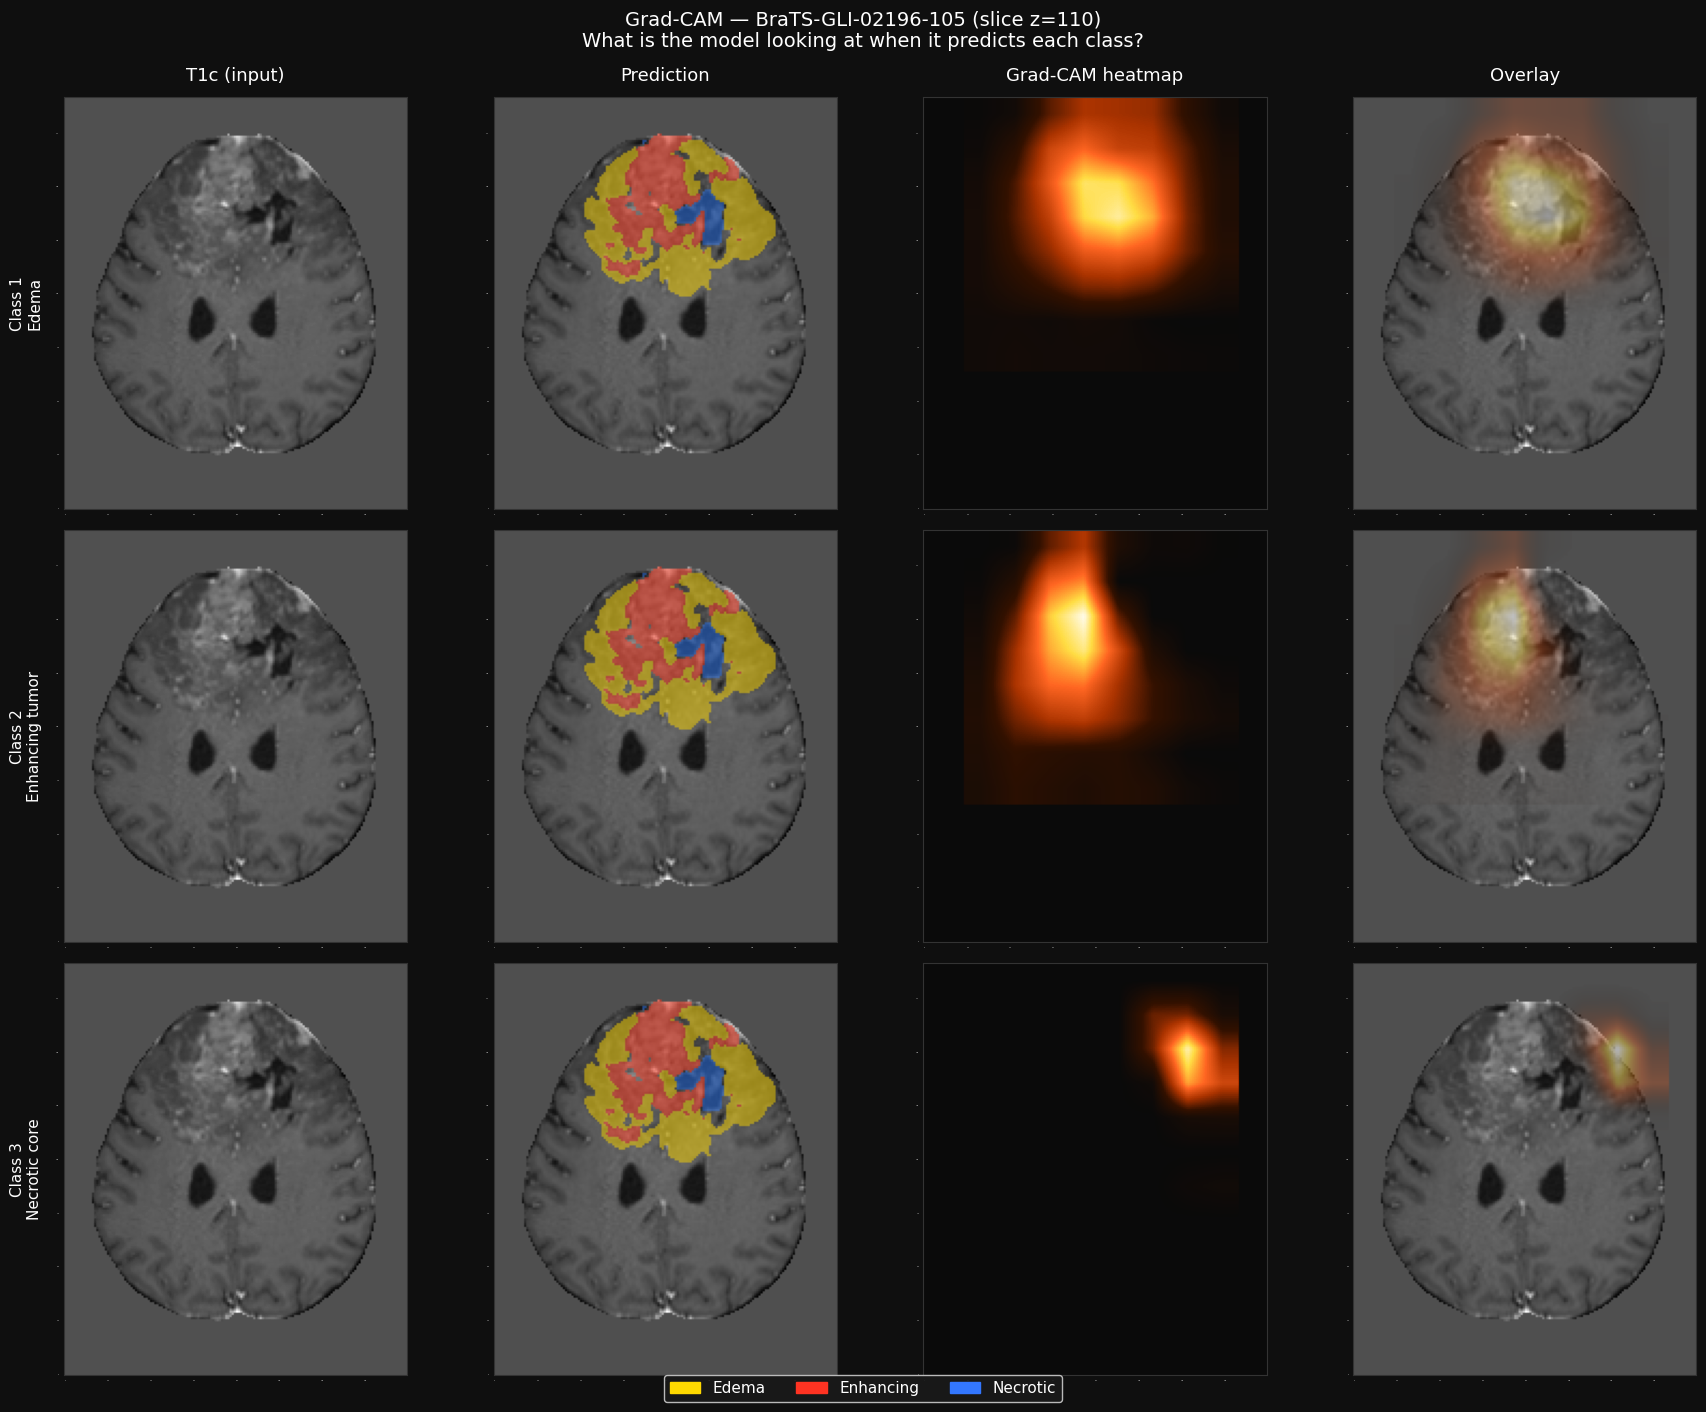


Saved: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\gradcam_BraTS-GLI-02196-105.png


In [6]:
# Orange-red colormap for Grad-CAM (medical imaging style)
gradcam_cmap = LinearSegmentedColormap.from_list(
    'gradcam',
    ['#0a0a0a', '#331100', '#aa3300', '#ff6622', '#ffdd44', '#ffffff']
)


def overlay_heatmap(mri, heatmap, seg_mask=None, alpha=0.55):
    """Overlay heatmap on grayscale MRI. Optionally outline seg_mask."""
    mri_n = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)
    rgb = np.stack([mri_n, mri_n, mri_n], axis=-1)

    hm_n = heatmap / (heatmap.max() + 1e-8)
    # Apply colormap to heatmap
    colored = gradcam_cmap(hm_n)[..., :3]
    # Blend where heatmap > threshold
    mask = hm_n > 0.05
    for c in range(3):
        rgb[..., c] = np.where(mask,
                                (1 - alpha * hm_n) * rgb[..., c] + alpha * hm_n * colored[..., c],
                                rgb[..., c])
    return np.clip(rgb, 0, 1)


def overlay_seg(mri, seg):
    mri_n = (mri - mri.min()) / (mri.max() - mri.min() + 1e-8)
    rgb = np.stack([mri_n, mri_n, mri_n], axis=-1)
    colors = {1: [1.0, 0.85, 0], 2: [1.0, 0.2, 0.1], 3: [0.2, 0.5, 1.0]}
    for lbl, color in colors.items():
        m = seg == lbl
        if m.any():
            rgb[m] = 0.5 * rgb[m] + 0.5 * np.array(color)
    return np.clip(rgb, 0, 1)


# Extract slice data
img_slice = result['image'][1, :, :, TARGET_SLICE].numpy().T   # T1c
seg_slice = pred[:, :, TARGET_SLICE].T
img_norm = (img_slice - img_slice.min()) / (img_slice.max() - img_slice.min() + 1e-8)

# Build figure
target_classes = [1, 2, 3]
fig, axes = plt.subplots(len(target_classes), 4, figsize=(18, 14))
fig.patch.set_facecolor('#0f0f0f')

col_titles = ['T1c (input)', 'Prediction', 'Grad-CAM heatmap', 'Overlay']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, color='white', fontsize=13, pad=12)

for row, cls in enumerate(target_classes):
    heatmap_slice = result['heatmaps'][cls][:, :, TARGET_SLICE].numpy().T

    axes[row, 0].imshow(img_norm, cmap='gray', origin='lower')
    axes[row, 1].imshow(overlay_seg(img_slice, seg_slice), origin='lower')
    im = axes[row, 2].imshow(heatmap_slice, cmap=gradcam_cmap, origin='lower', vmin=0, vmax=1)
    axes[row, 3].imshow(overlay_heatmap(img_slice, heatmap_slice), origin='lower')

    axes[row, 0].set_ylabel(
        f'Class {cls}\n{CLASS_NAMES[cls]}',
        color='white', fontsize=11, labelpad=10,
    )

    for col in range(4):
        axes[row, col].tick_params(colors='white', labelsize=0, length=0)
        axes[row, col].set_facecolor('#0f0f0f')
        for s in axes[row, col].spines.values():
            s.set_edgecolor('#333')

legend_patches = [
    mpatches.Patch(color='#FFD900', label='Edema'),
    mpatches.Patch(color='#FF3322', label='Enhancing'),
    mpatches.Patch(color='#3377FF', label='Necrotic'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           facecolor='#1a1a1a', labelcolor='white', fontsize=11,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.01))

plt.suptitle(
    f'Grad-CAM — {result["case_id"]} (slice z={TARGET_SLICE})\n'
    f'What is the model looking at when it predicts each class?',
    color='white', fontsize=14, y=0.99)

plt.tight_layout()
save_path = OUTPUTS_DIR / f'gradcam_{result["case_id"]}.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'\nSaved: {save_path}')

## 6. Quantitative sanity check — does Grad-CAM align with the prediction?

If the model is working correctly, Grad-CAM activation should be HIGH where the model predicts that class, and LOW elsewhere. We measure this overlap numerically.

In [7]:
print('=' * 60)
print(f'Grad-CAM — Prediction alignment check')
print(f'Case: {result["case_id"]}')
print('=' * 60)

for cls in target_classes:
    name = CLASS_NAMES[cls]
    hm = result['heatmaps'][cls].numpy()
    pred_mask = (pred == cls)
    other_mask = (pred > 0) & (pred != cls)
    bg_mask = (pred == 0)

    mean_in_pred  = hm[pred_mask].mean()  if pred_mask.any()  else 0.0
    mean_in_other = hm[other_mask].mean() if other_mask.any() else 0.0
    mean_in_bg    = hm[bg_mask].mean()    if bg_mask.any()    else 0.0

    alignment_ratio = mean_in_pred / (mean_in_bg + 1e-8)

    print(f'\n{name}:')
    print(f'  Mean activation inside predicted {name:18s}: {mean_in_pred:.4f}')
    print(f'  Mean activation inside other tumor classes    : {mean_in_other:.4f}')
    print(f'  Mean activation in background                 : {mean_in_bg:.4f}')
    print(f'  Signal-to-background ratio                    : {alignment_ratio:.2f}×')

    if alignment_ratio > 5:
        print(f'  ✓ STRONG alignment — model focuses on {name}')
    elif alignment_ratio > 2:
        print(f'  ~ moderate alignment')
    else:
        print(f'  ⚠ weak alignment — investigate')

print('\n' + '=' * 60)

Grad-CAM — Prediction alignment check
Case: BraTS-GLI-02196-105

Edema:
  Mean activation inside predicted Edema             : 0.4393
  Mean activation inside other tumor classes    : 0.6412
  Mean activation in background                 : 0.0462
  Signal-to-background ratio                    : 9.50×
  ✓ STRONG alignment — model focuses on Edema

Enhancing tumor:
  Mean activation inside predicted Enhancing tumor   : 0.5756
  Mean activation inside other tumor classes    : 0.3069
  Mean activation in background                 : 0.0388
  Signal-to-background ratio                    : 14.83×
  ✓ STRONG alignment — model focuses on Enhancing tumor

Necrotic core:
  Mean activation inside predicted Necrotic core     : 0.0494
  Mean activation inside other tumor classes    : 0.0463
  Mean activation in background                 : 0.0052
  Signal-to-background ratio                    : 9.52×
  ✓ STRONG alignment — model focuses on Necrotic core



## 7. Compare all 3 classes on ONE slice

Side-by-side heatmaps — are they visually distinct? Each class should activate in a different region of the tumor.

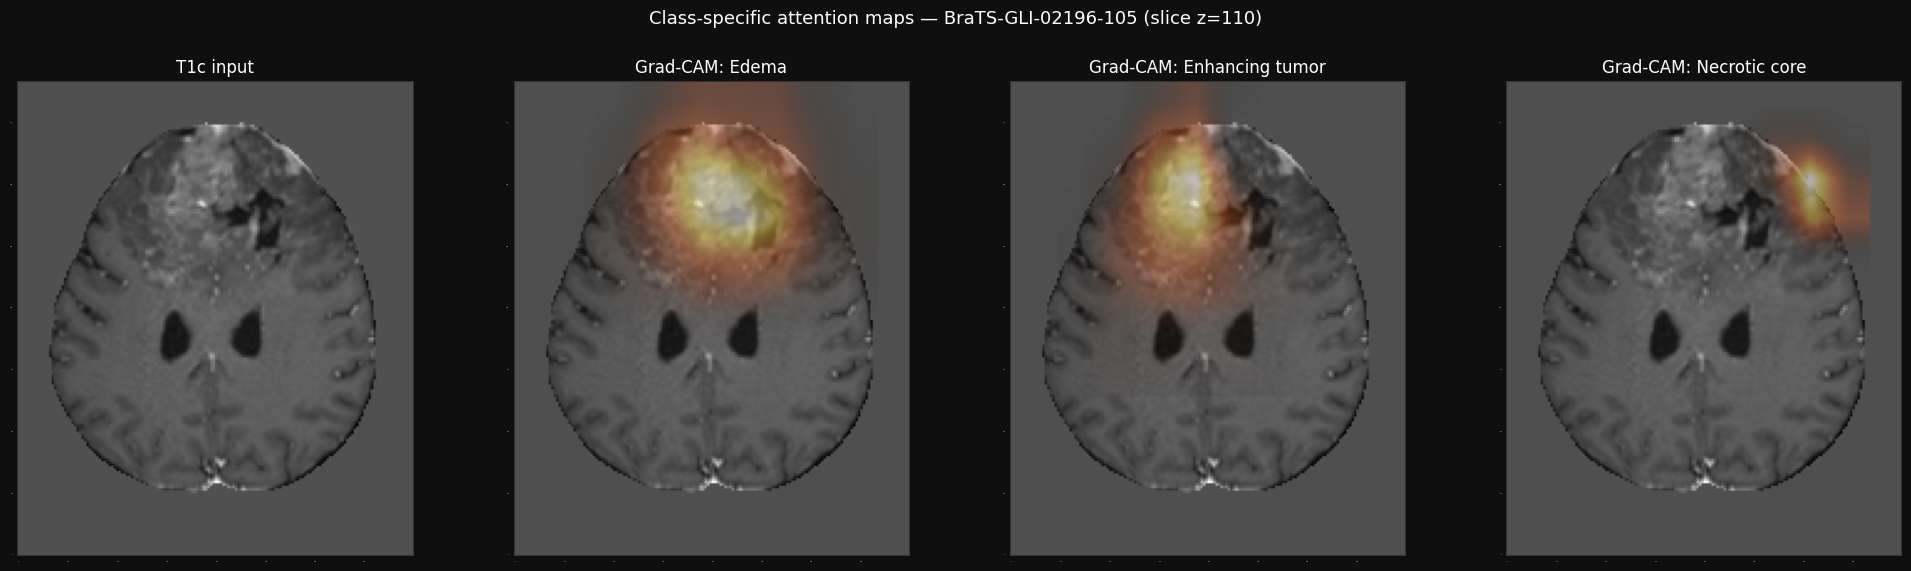

Saved: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\gradcam_compare_BraTS-GLI-02196-105.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
fig.patch.set_facecolor('#0f0f0f')

axes[0].imshow(img_norm, cmap='gray', origin='lower')
axes[0].set_title('T1c input', color='white', fontsize=12)

for col, cls in enumerate(target_classes, start=1):
    hm_slice = result['heatmaps'][cls][:, :, TARGET_SLICE].numpy().T
    axes[col].imshow(overlay_heatmap(img_slice, hm_slice), origin='lower')
    axes[col].set_title(
        f'Grad-CAM: {CLASS_NAMES[cls]}',
        color='white', fontsize=12,
    )

for ax in axes:
    ax.tick_params(colors='white', labelsize=0, length=0)
    ax.set_facecolor('#0f0f0f')
    for s in ax.spines.values():
        s.set_edgecolor('#333')

plt.suptitle(
    f'Class-specific attention maps — {result["case_id"]} (slice z={TARGET_SLICE})',
    color='white', fontsize=13, y=1.02,
)
plt.tight_layout()
save_path2 = OUTPUTS_DIR / f'gradcam_compare_{result["case_id"]}.png'
plt.savefig(save_path2, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Saved: {save_path2}')

## 8. Multi-slice axial strip — where does the model look across depth?

Shows 6 axial slices spanning the tumor. For each, overlay the enhancing-tumor Grad-CAM. Confirms the model attends to tumor consistently across the volume.

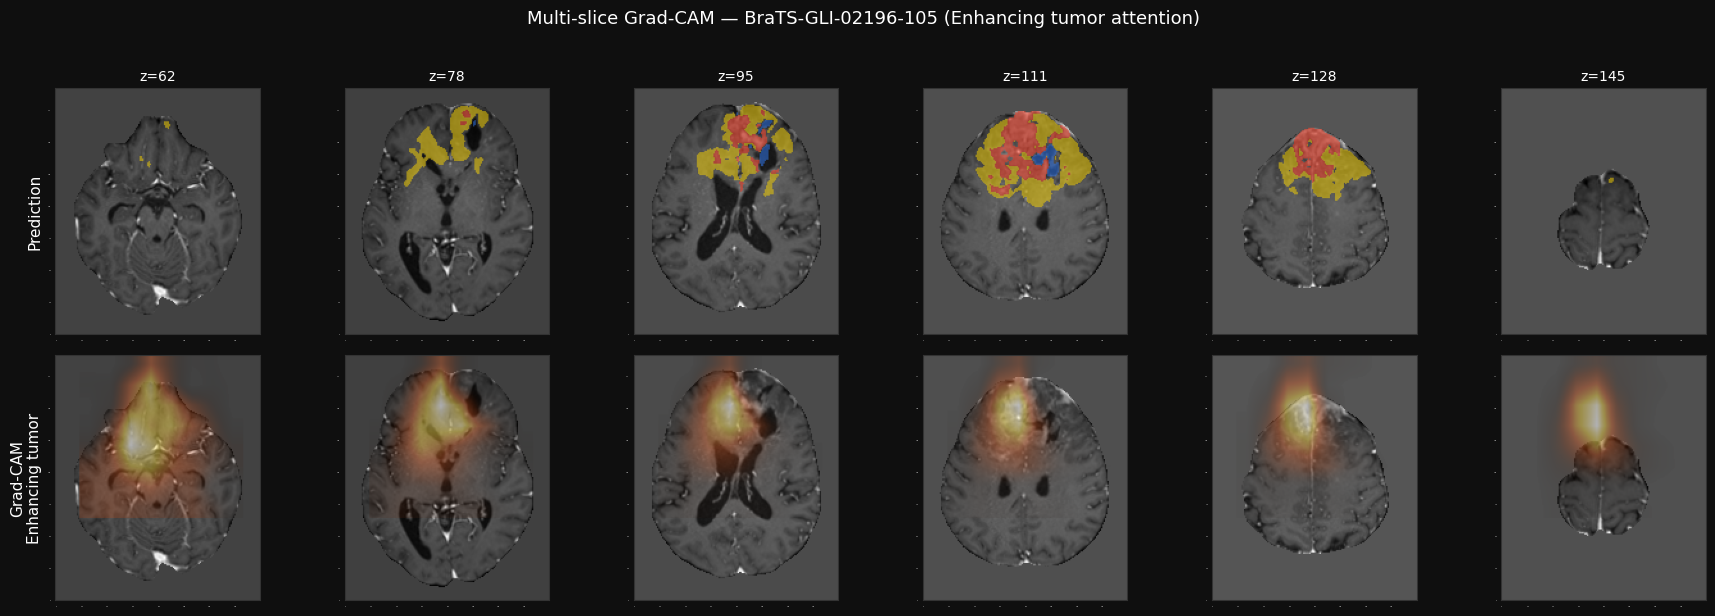

Saved: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\gradcam_multislice_BraTS-GLI-02196-105.png


In [9]:
# Pick 6 slices evenly distributed across the tumor extent
tumor_slices = np.where(tumor_per_slice > 0)[0]
if len(tumor_slices) >= 6:
    selected = np.linspace(tumor_slices[0], tumor_slices[-1], 6, dtype=int)
else:
    selected = tumor_slices

TARGET_CLASS = 2   # enhancing tumor (most clinically interesting)

fig, axes = plt.subplots(2, len(selected), figsize=(3 * len(selected), 6))
fig.patch.set_facecolor('#0f0f0f')

for col, z in enumerate(selected):
    img_sl = result['image'][1, :, :, z].numpy().T
    seg_sl = pred[:, :, z].T
    hm_sl  = result['heatmaps'][TARGET_CLASS][:, :, z].numpy().T

    img_n = (img_sl - img_sl.min()) / (img_sl.max() - img_sl.min() + 1e-8)

    axes[0, col].imshow(overlay_seg(img_sl, seg_sl), origin='lower')
    axes[0, col].set_title(f'z={z}', color='white', fontsize=10)
    axes[1, col].imshow(overlay_heatmap(img_sl, hm_sl), origin='lower')

    for row in range(2):
        axes[row, col].tick_params(colors='white', labelsize=0, length=0)
        axes[row, col].set_facecolor('#0f0f0f')
        for s in axes[row, col].spines.values():
            s.set_edgecolor('#333')

axes[0, 0].set_ylabel('Prediction', color='white', fontsize=11)
axes[1, 0].set_ylabel(f'Grad-CAM\n{CLASS_NAMES[TARGET_CLASS]}',
                        color='white', fontsize=11)

plt.suptitle(
    f'Multi-slice Grad-CAM — {result["case_id"]} ({CLASS_NAMES[TARGET_CLASS]} attention)',
    color='white', fontsize=13, y=1.02,
)
plt.tight_layout()
save_path3 = OUTPUTS_DIR / f'gradcam_multislice_{result["case_id"]}.png'
plt.savefig(save_path3, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'Saved: {save_path3}')